In [1]:
import warnings 
warnings.filterwarnings("ignore")

import shap
import pandas as pd
import numpy as np
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,f1_score, roc_auc_score


In [2]:
# Load dataset
sample = pd.read_csv("llm_outputs.csv")

labels = {'true', 'false', 'mixture', 'unproven'}

In [3]:
# Feature Engineering
def extract_features (df):
    """
    Extract interpretable features for SHAP Explainer

    Categories:
    1. Ground truth categories for SHAP
    2. Textual statistics eg response length
    3. Health domain keywords eg cure, vaccine
    4. Lingustic markers eg certainty, emotions
    5. Claim type heuristics eg causal

    """
    claims = df["claim"]
    features = pd.DataFrame(index = df.index)

    # Ground truth features
    for label in labels:
        features[f"gt_is_{label}"] = (df["label"] == label).astype(int)

    # Textual statistics
    features["char_length"] = claims.str.len()
    features["word_count"] = claims.str.split().str.len()
    features["avg_word_length"] = (features["char_length"] / features["word_count"]).round(2)
    features["has_numbers"] = claims.str.contains(r"\d", regex=True).astype(int)
    features["num_commas"] = claims.str.count(",")
    features["sentence_count"] = claims.str.count(r"[.!?]") + 1

    # Health domain keywords
    features["mentions_cure"] = claims.str.lower().str.contains(r"\bcure[sd]?\b", regex=True).astype(int)
    features["mentions_cause"] = claims.str.lower().str.contains(r"\bcause[sd]?\b", regex=True).astype(int)
    features["mentions_prevent"] = claims.str.lower().str.contains(r"\bprevents?\b", regex=True).astype(int)
    features["mentions_risk"] = claims.str.lower().str.contains(r"\brisk\b", regex=True).astype(int)
    features["mentions_vaccine"] = claims.str.lower().str.contains(r"\bvaccin", regex=True).astype(int)
    features["mentions_cancer"] = claims.str.lower().str.contains(r"\bcancer\b", regex=True).astype(int)
    features["mentions_treatment"] = claims.str.lower().str.contains(r"\b(treat|therap|medicat|drug|antibiot)", regex=True).astype(int)
    features["mentions_supplement"] = claims.str.lower().str.contains(r"\b(supplement|vitamin|mineral|probiotic|collagen)", regex=True).astype(int)
    features["mentions_death"] = claims.str.lower().str.contains(r"\b(death|die[sd]?|dying|kill|fatal|lethal|mortalit)", regex=True).astype(int)

    # Sentiment/lingusitic markers
    features["has_absolute_language"] = claims.str.lower().str.contains(r"\b(always|never|all|every|completely|entirely|definitely|"r"proven|100|guarantee|certainly)\b", regex=True).astype(int)
    features["has_hedge_language"] = claims.str.lower().str.contains(r"\b(may|might|could|possibly|some|certain|suggest|"r"associated|linked|appears?|seems?)\b", regex=True).astype(int)
    features["has_negation"] = claims.str.lower().str.contains(r"\b(not|no|never|don\'t|doesn\'t|cannot|can\'t|won\'t|isn\'t)\b",regex=True).astype(int)
    features["has_emotional_language"] = claims.str.lower().str.contains(r"\b(dangerous|deadly|toxic|kill|harm|damage|destroy|"r"miracle|shocking|alarming|terrifying)\b", regex=True).astype(int)
    features["has_jargon"] = claims.str.lower().str.contains(r"\b(neural|autoimmune|electromagnetic|alkaline|homeopathic|"r"epidemiolog|pathogen|antioxidant|metabolism|cardiovascular|"r"carcinogen|immunolog|oncolog|peptide|cytokine)\b", regex=True).astype(int)

    # Claim type heuristics
    features["is_causal_claim"] = claims.str.lower().str.contains(r"\b(cause|lead to|result in|increase|reduce|prevent|protect)\b",regex=True).astype(int)
    features["is_efficacy_claim"] = claims.str.lower().str.contains(r"\b(cure|treat|heal|fix|remedy|effective|works|relieve)\b",regex=True).astype(int)
    features["is_comparative_claim"] = claims.str.lower().str.contains(r"\b(more|less|better|worse|than|compared|superior|inferior)\b",regex=True).astype(int)

    return features

In [4]:
# Extract features
X_features = extract_features(sample)

# Add TF-idf features
tfidf = TfidfVectorizer(max_features=50, stop_words="english", ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(sample["claim"])
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=[f"tfidf_{name}" for name in tfidf.get_feature_names_out()],
    index=X_features.index,
)

# Combine all features
X = pd.concat([X_features, tfidf_df], axis=1)
y = sample["llm_correct"].values

print(f"Interpretable features: {len(X_features.columns)}")
print(f"TF-IDF features: {len(tfidf_df.columns)}")
print(f"Total features: {X.shape[1]}")

Interpretable features: 27
TF-IDF features: 50
Total features: 77


In [5]:
# Training XGBoost Classifier to predict LLM correctness
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False,
)

clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

print(f"\n  XGboost Classifier Performance:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.3f}")
try:
    print(f"AUC-ROC:   {roc_auc_score(y_test, y_pred_proba):.3f}")
except:
    print(f"AUC-ROC:   N/A")

print(f"\n  Classification Report:")
print(classification_report(
    y_test, y_pred, target_names=["LLM Wrong", "LLM Correct"]
))
 


  XGboost Classifier Performance:
Accuracy:  0.680
F1 Score:  0.590
AUC-ROC:   0.729

  Classification Report:
              precision    recall  f1-score   support

   LLM Wrong       0.71      0.76      0.74        59
 LLM Correct       0.62      0.56      0.59        41

    accuracy                           0.68       100
   macro avg       0.67      0.66      0.66       100
weighted avg       0.68      0.68      0.68       100



In [6]:
# SHAP Explanations
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (100, 77)


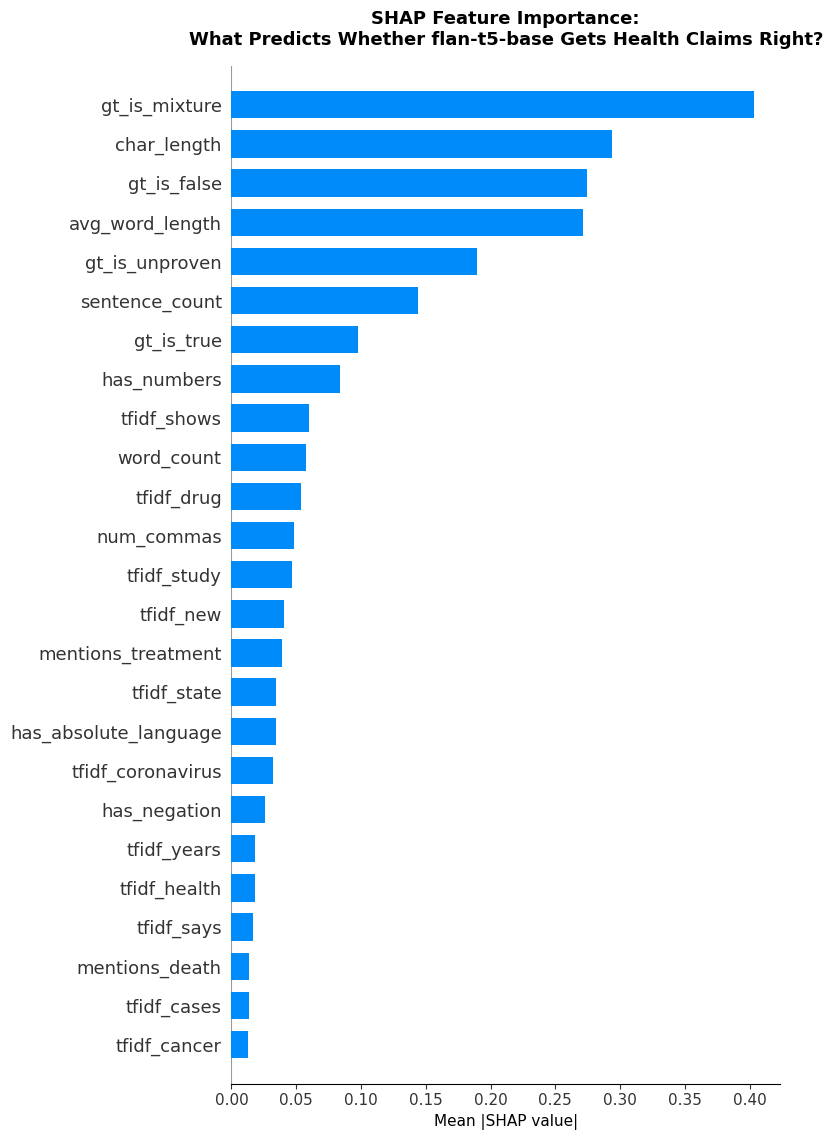

In [7]:
# Plotting results

# 1. Global Feature importance
fig, ax = plt.subplots(figsize=(10, 9))
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=25, show=False)
plt.title("SHAP Feature Importance:\nWhat Predicts Whether flan-t5-base Gets Health Claims Right?",fontsize=13, fontweight="bold", pad=15,)
plt.xlabel("Mean |SHAP value|", fontsize=11)
plt.tight_layout()

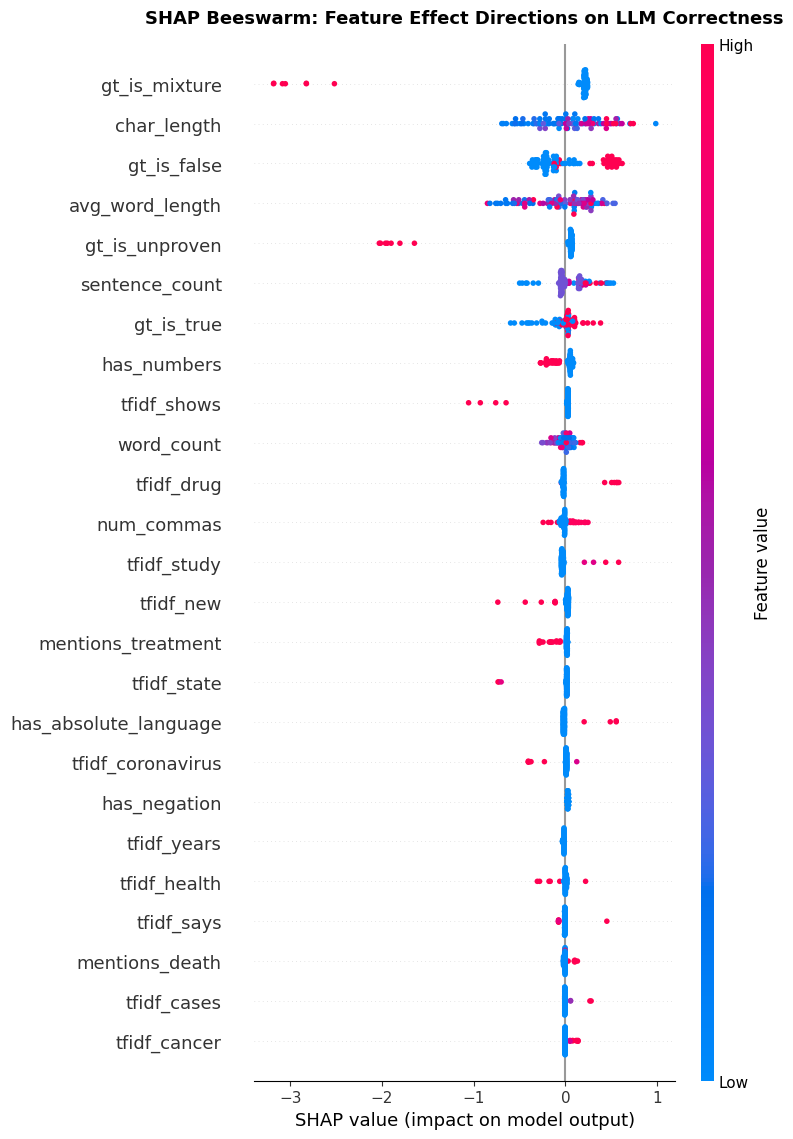

In [8]:
# Beeswarm plot
fig, ax = plt.subplots(figsize=(10, 9))
shap.summary_plot(shap_values, X_test, max_display=25, show=False)
plt.title("SHAP Beeswarm: Feature Effect Directions on LLM Correctness",fontsize=13, fontweight="bold", pad=15,)
plt.tight_layout()

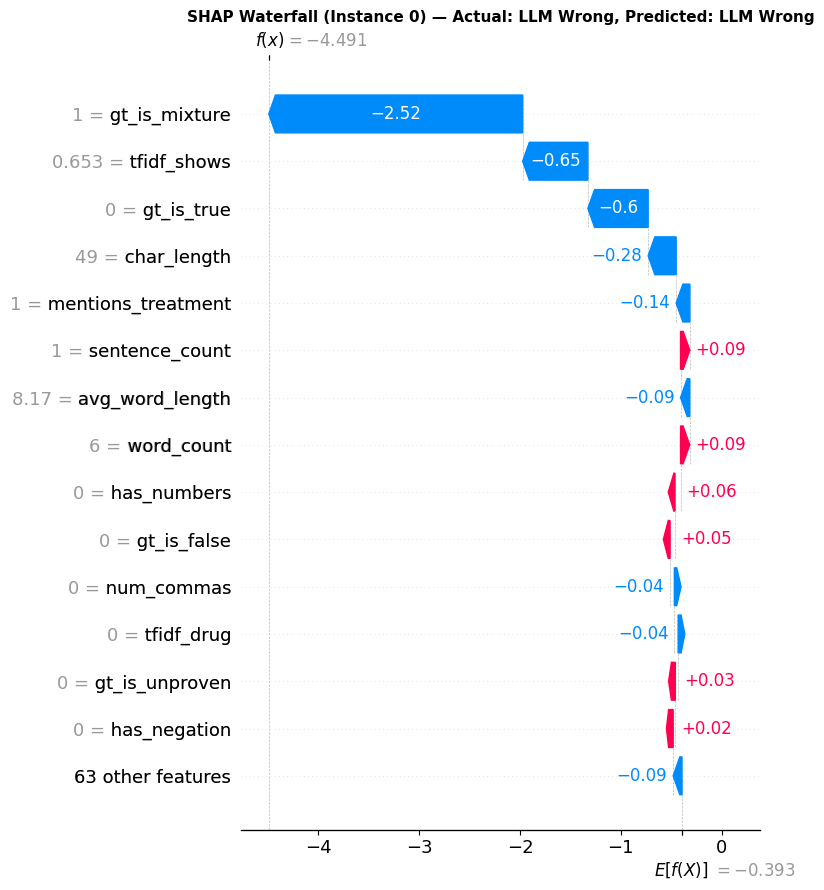

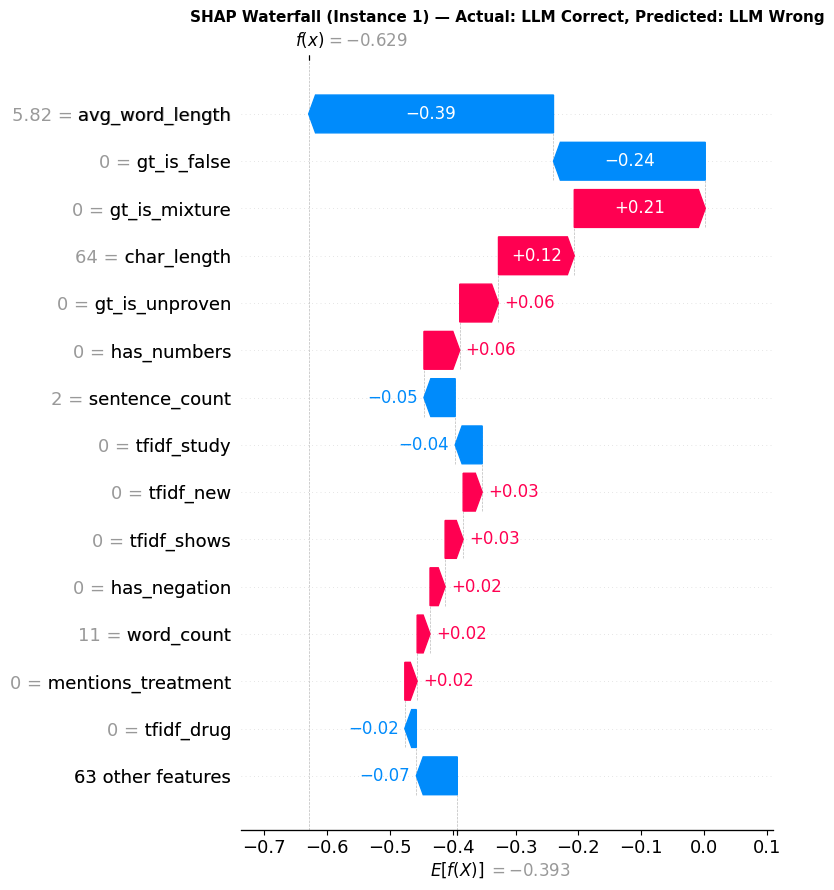

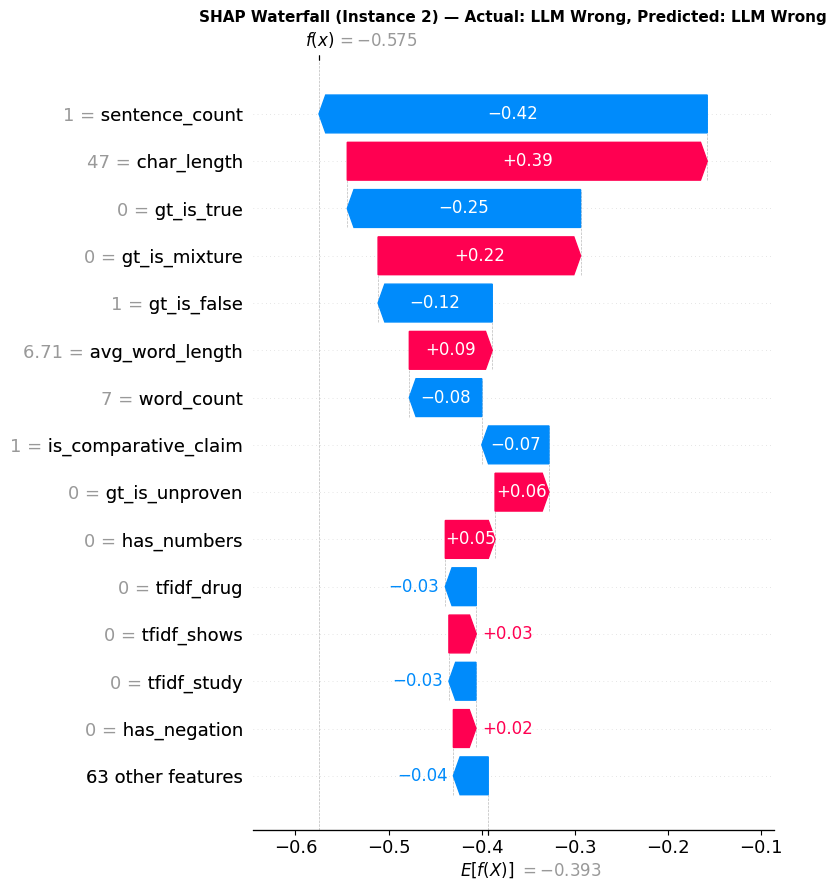

In [9]:
# Waterafll plots
wrong_idx = np.where(y_test == 0)[0]
right_idx = np.where(y_test == 1)[0]
showcase = []
if len(wrong_idx) > 0:
    showcase.append(("wrong", wrong_idx[0]))
if len(right_idx) > 0:
    showcase.append(("correct", right_idx[0]))
if len(wrong_idx) > 1:
    showcase.append(("wrong", wrong_idx[1]))
 
for i, (lbl, idx) in enumerate(showcase):
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X_test.iloc[idx],
            feature_names=X_test.columns.tolist(),
        ),
        max_display=15,
        show=False,
    )
    actual = "Correct" if y_test[idx] == 1 else "Wrong"
    predicted = "Correct" if y_pred[idx] == 1 else "Wrong"
    plt.title(
        f"SHAP Waterfall (Instance {i}) — "
        f"Actual: LLM {actual}, Predicted: LLM {predicted}",
        fontsize=11, fontweight="bold",
    )
    plt.tight_layout()

In [10]:
# Analysis and evaluation
# Feature importance table
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": mean_abs_shap,
}).sort_values("mean_abs_shap", ascending=False)
 
print("\n  Top 20 features predicting LLM correctness:")
print("  " + "-" * 55)
for _, row in feature_importance.head(20).iterrows():
    print(f"  {row['feature']:40s} {row['mean_abs_shap']:.4f}")


  Top 20 features predicting LLM correctness:
  -------------------------------------------------------
  gt_is_mixture                            0.4033
  char_length                              0.2934
  gt_is_false                              0.2745
  avg_word_length                          0.2713
  gt_is_unproven                           0.1899
  sentence_count                           0.1438
  gt_is_true                               0.0976
  has_numbers                              0.0837
  tfidf_shows                              0.0601
  word_count                               0.0576
  tfidf_drug                               0.0534
  num_commas                               0.0487
  tfidf_study                              0.0471
  tfidf_new                                0.0408
  mentions_treatment                       0.0394
  tfidf_state                              0.0347
  has_absolute_language                    0.0340
  tfidf_coronavirus                        0.

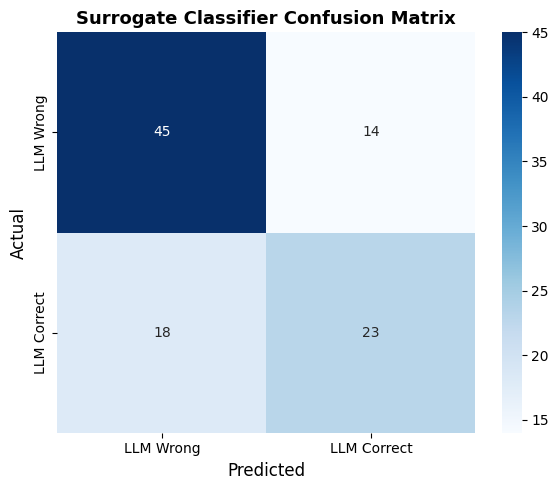

In [11]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["LLM Wrong", "LLM Correct"],
    yticklabels=["LLM Wrong", "LLM Correct"], ax=ax,
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
ax.set_title("Surrogate Classifier Confusion Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

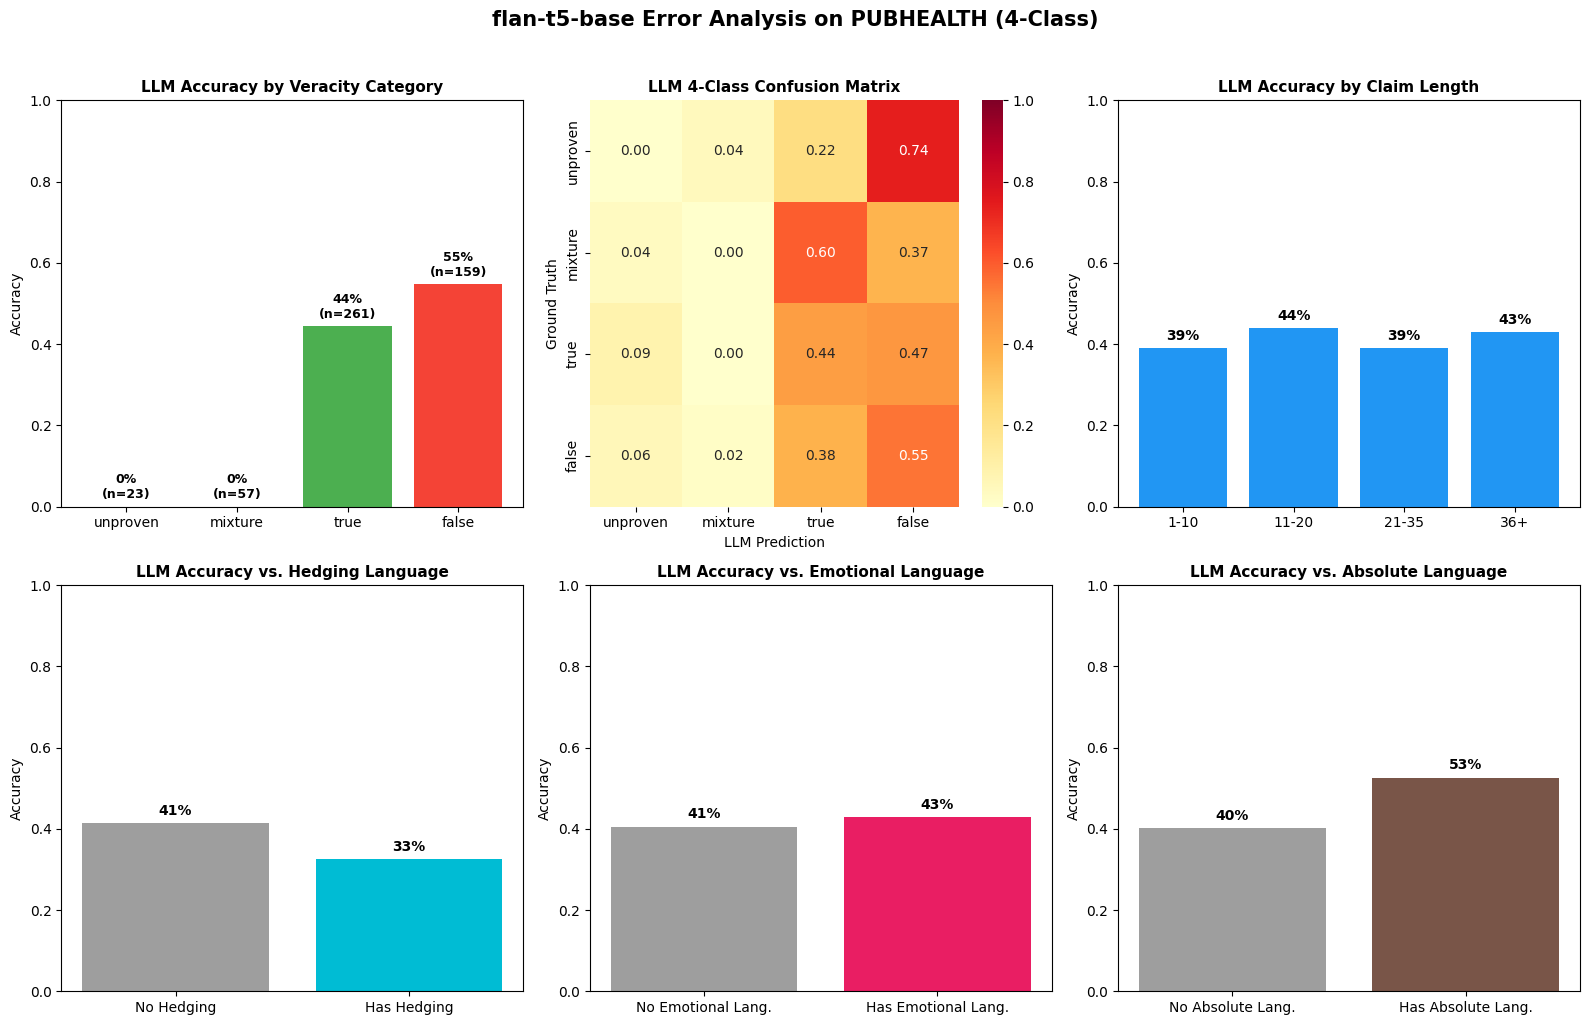

In [12]:
# LLM Error analysis
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# LLM accuracy by veracity 
colors_4 = {
    "true": "#4CAF50", "false": "#F44336",
    "mixture": "#FF9800", "unproven": "#9C27B0",
}
present_labels = [l for l in labels if l in sample["label"].unique()]
acc_by_cat = sample.groupby("label")["llm_correct"].mean().reindex(present_labels)
counts_by_cat = sample["label"].value_counts().reindex(present_labels)
axes[0, 0].bar(
    present_labels, acc_by_cat.values,
    color=[colors_4[l] for l in present_labels],
)
axes[0, 0].set_title("LLM Accuracy by Veracity Category", fontweight="bold", fontsize=11)
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].set_ylim(0, 1)
for i, (v, n) in enumerate(zip(acc_by_cat.values, counts_by_cat.values)):
    axes[0, 0].text(
        i, v + 0.02, f"{v:.0%}\n(n={n})", ha="center", fontsize=9, fontweight="bold"
    )

# LLM Confusion matrix
llm_cm = pd.crosstab(
    sample["label"], sample["llm_prediction"], normalize="index"
).reindex(index=present_labels, columns=present_labels, fill_value=0)
sns.heatmap(
    llm_cm, annot=True, fmt=".2f", cmap="YlOrRd",
    xticklabels=present_labels, yticklabels=present_labels,
    ax=axes[0, 1], vmin=0, vmax=1,
)
axes[0, 1].set_title("LLM 4-Class Confusion Matrix", fontweight="bold", fontsize=11)
axes[0, 1].set_xlabel("LLM Prediction")
axes[0, 1].set_ylabel("Ground Truth")

# Accuracy by claim length
sample["word_bin"] = pd.cut(
    sample["claim"].str.split().str.len(),
    bins=[0, 10, 20, 35, 1000],
    labels=["1-10", "11-20", "21-35", "36+"],
)
acc_by_len = sample.groupby("word_bin", observed=True)["llm_correct"].mean()
axes[0, 2].bar(acc_by_len.index.astype(str), acc_by_len.values, color="#2196F3")
axes[0, 2].set_title("LLM Accuracy by Claim Length", fontweight="bold", fontsize=11)
axes[0, 2].set_ylabel("Accuracy")
axes[0, 2].set_ylim(0, 1)
for i, v in enumerate(acc_by_len.values):
    axes[0, 2].text(i, v + 0.02, f"{v:.0%}", ha="center", fontweight="bold")

# Accuracy by hedge length
sample["has_hedge"] = sample["claim"].str.lower().str.contains(
    r"\b(may|might|could|some|but|however|possibly)\b", regex=True
)
acc_hedge = sample.groupby("has_hedge")["llm_correct"].mean()
axes[1, 0].bar(
    ["No Hedging", "Has Hedging"], acc_hedge.values, color=["#9E9E9E", "#00BCD4"]
)
axes[1, 0].set_title("LLM Accuracy vs. Hedging Language", fontweight="bold", fontsize=11)
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].set_ylim(0, 1)
for i, v in enumerate(acc_hedge.values):
    axes[1, 0].text(i, v + 0.02, f"{v:.0%}", ha="center", fontweight="bold")

# Accuracy by emotional language
sample["has_emo"] = sample["claim"].str.lower().str.contains(
    r"\b(dangerous|deadly|toxic|kill|harm|damage|destroy|miracle)\b", regex=True
)
acc_emo = sample.groupby("has_emo")["llm_correct"].mean()
axes[1, 1].bar(
    ["No Emotional Lang.", "Has Emotional Lang."],
    acc_emo.values, color=["#9E9E9E", "#E91E63"],
)
axes[1, 1].set_title("LLM Accuracy vs. Emotional Language", fontweight="bold", fontsize=11)
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].set_ylim(0, 1)
for i, v in enumerate(acc_emo.values):
    axes[1, 1].text(i, v + 0.02, f"{v:.0%}", ha="center", fontweight="bold")

# Accuracy by absolute language
sample["has_abs"] = sample["claim"].str.lower().str.contains(
    r"\b(always|never|all|every|completely|proven|definitely)\b", regex=True
)
acc_abs = sample.groupby("has_abs")["llm_correct"].mean()
axes[1, 2].bar(
    ["No Absolute Lang.", "Has Absolute Lang."],
    acc_abs.values, color=["#9E9E9E", "#795548"],
)
axes[1, 2].set_title("LLM Accuracy vs. Absolute Language", fontweight="bold", fontsize=11)
axes[1, 2].set_ylabel("Accuracy")
axes[1, 2].set_ylim(0, 1)
for i, v in enumerate(acc_abs.values):
    axes[1, 2].text(i, v + 0.02, f"{v:.0%}", ha="center", fontweight="bold") 

plt.suptitle(
    "flan-t5-base Error Analysis on PUBHEALTH (4-Class)",
    fontsize=15, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()